# 第四章补充 4.1：模型压缩

ch4 介绍了预训练大模型的原理（BERT、GPT）。这一章解决大模型部署的核心工程问题：**模型太大怎么压小？**

三条主要路线：知识蒸馏、剪枝、量化。

## 目录

| 章节 | 内容 |
|------|------|
| **4.1.1 一个模型包含哪些文件** | config、tokenizer、safetensors 各自的作用 |
| **4.1.2 为什么需要模型压缩** | 大模型的部署困境：显存、延迟、成本 |
| **4.1.3 知识蒸馏** | Teacher-Student 框架、软标签、DistilBERT 案例 |
| **4.1.4 剪枝与量化** | 结构化剪枝、INT8/INT4 量化、实际收益对比 |

In [ ]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False

## 4.1.1 一个模型包含哪些文件

在 HuggingFace 或 ModelScope 上下载一个模型（以 Qwen2.5-0.5B-Instruct 为例），解压后的目录是这样的：

```
Qwen2.5-0.5B-Instruct/
│
├── config.json                ← 模型骨架定义（最重要）
├── generation_config.json     ← 推理默认参数
│
├── tokenizer.json             ← 完整词表 + 分词规则（6.7 MB）
├── tokenizer_config.json      ← 分词器配置，含 chat template
├── vocab.json                 ← token → id 映射（2.6 MB）
├── merges.txt                 ← BPE 合并规则（1.6 MB）
│
└── model.safetensors          ← 参数本体（0.5B ≈ 1 GB）
                                  7B 以上会拆成多个分片：
                                  model-00001-of-00004.safetensors
                                  model-00002-of-00004.safetensors
                                  ...
```

---

### config.json — 网络骨架

这是最重要的配置文件，定义了整个网络的结构。Qwen2.5-0.5B 的实际内容：

```json
{
  "hidden_size": 896,
  "num_hidden_layers": 24,
  "num_attention_heads": 14,
  "num_key_value_heads": 2,
  "intermediate_size": 4864,
  "vocab_size": 151936,
  "max_position_embeddings": 32768
}
```

这几个数字决定了模型的规模：
- `hidden_size`：每个 token 的向量维度，越大表达能力越强
- `num_hidden_layers`：Transformer 层数，越多理解能力越强
- `num_key_value_heads`：这里只有 2，而 Q 有 14 个头——这是 **GQA（分组查询注意力）**，多个 Q 头共享同一组 K/V，大幅节省推理时的显存
- `intermediate_size`：FFN 层的中间维度，通常是 hidden_size 的 4-5 倍

光靠这几个数字就能估算参数量：

```
词嵌入矩阵：  vocab_size × hidden_size = 151936 × 896 ≈ 1.36 亿
每层 Attention：Q/K/V/O 四个矩阵 ≈ 4 × 896 × 896 ≈ 3.2M（K/V 更小）
每层 FFN：    gate/up/down 三个矩阵 ≈ 3 × 896 × 4864 ≈ 13.1M
× 24 层 + 词嵌入 ≈ 总计约 5 亿参数
```

---

### model.safetensors — 参数本体

本质是一张**键值表**，键是参数名，值是多维数组（张量）。打开来看：

```
model.embed_tokens.weight              [151936, 896]   ← 词嵌入，把 token id 变成向量
model.layers.0.self_attn.q_proj.weight [896, 896]      ← 第 0 层的 Q 投影矩阵
model.layers.0.self_attn.k_proj.weight [128, 896]      ← K 投影（GQA，只有 2 头×64维）
model.layers.0.self_attn.v_proj.weight [128, 896]
model.layers.0.self_attn.o_proj.weight [896, 896]      ← 输出投影
model.layers.0.mlp.gate_proj.weight    [4864, 896]     ← FFN gate（SwiGLU 结构）
model.layers.0.mlp.up_proj.weight      [4864, 896]
model.layers.0.mlp.down_proj.weight    [896, 4864]
model.layers.0.input_layernorm.weight  [896]           ← LayerNorm，很小
...（layers.1 到 layers.23 结构完全相同）
model.norm.weight                      [896]           ← 最后一层 LayerNorm
lm_head.weight                         ← 和 embed_tokens 共享（tie_word_embeddings=true）
```

**safetensors** 是 HuggingFace 推出的格式，比旧的 `.bin`（实际上是 pickle）更安全、加载更快（支持内存映射，不需要把整个文件读进内存）。

---

### tokenizer 相关文件 — 把文字变成数字

模型本身不认识文字，只认识整数 ID。tokenizer 的工作就是文字 ↔ ID 的双向转换。

**vocab.json**：151936 个 token 及其 ID，例如：
```json
"你": 87,  "好": 273,  "Ġhello": 15339,  "<|im_start|>": 151644
```

**merges.txt**：BPE 合并规则，决定怎么把字符拼成 token。例如把 `h e l l o` 逐步合并成 `hello`。

**tokenizer_config.json** 里还有一段关键内容：**chat_template**——这是一段 Jinja2 模板，定义了如何把多轮对话拼装成模型能理解的字符串格式。Qwen 用的是 ChatML 格式：
```
<|im_start|>system
You are Qwen...<|im_end|>
<|im_start|>user
你好<|im_end|>
<|im_start|>assistant
```

---

### generation_config.json — 推理默认参数

控制模型生成文本时的行为，不传参数时就用这里的值：

```json
{
  "temperature": 0.7,       ← 控制随机性，越低越确定
  "top_p": 0.8,             ← 核采样，只从概率累计到 80% 的 token 里选
  "top_k": 20,              ← 每步只考虑概率最高的 20 个 token
  "repetition_penalty": 1.1 ← 对已出现的 token 降权，减少重复
}
```

---

### 大模型和小模型的区别在哪里？

所有文件都一样，区别只在 `config.json` 里的几个数字：

| 模型 | hidden_size | 层数 | 参数量 | safetensors 大小（BF16）|
|------|-------------|------|--------|------------------------|
| Qwen2.5-0.5B | 896 | 24 | 0.5B | ~1 GB |
| Qwen2.5-7B | 3584 | 28 | 7B | ~14 GB |
| Qwen2.5-72B | 8192 | 80 | 72B | ~144 GB |

`hidden_size` 翻 4 倍（896→3584），参数量翻了约 14 倍——因为参数量和 `hidden_size²` 成正比（矩阵乘法）。

**这就是为什么需要模型压缩**：14GB 的权重文件，加上推理时的 KV Cache 和激活值，单张消费级显卡（8-24 GB）根本装不下。下一节详细讲这个困境。

## 4.1.2 为什么需要模型压缩

### 大模型的部署困境

GPT-3 有 1750 亿参数，每个参数用 FP16 存储需要 2 字节：

$$1750 \times 10^8 \times 2 \text{ bytes} = 350 \text{ GB}$$

单张 A100 显卡只有 80GB 显存，加载 GPT-3 至少需要 **5 张 A100**——这还没算推理时的 KV Cache、激活值等额外开销。

**三个核心矛盾：**

| 困境 | 具体表现 | 影响 |
|------|----------|------|
| **显存墙** | 模型权重本身就超过单卡容量 | 必须多卡并行，成本倍增 |
| **延迟瓶颈** | 推理需逐层计算，层数越多越慢 | 实时场景（语音助手、搜索）无法接受 |
| **部署成本** | 云端推理每次调用需高端 GPU | API 定价高，端侧部署不可能 |

**目标**：在可接受的精度损失内，**大幅降低模型的参数量、内存占用和推理时间**。

---

### 三条主要技术路线

```
原始大模型（Teacher）
       │
       ├─── 知识蒸馏（Distillation）─── 训练一个小模型模仿大模型的行为
       │
       ├─── 剪枝（Pruning）──────────── 删除模型中不重要的权重或结构
       │
       └─── 量化（Quantization）────── 降低权重的数值精度（FP32→INT8→INT4）
```

三种方法可以**叠加使用**：DistilBERT 先用蒸馏压缩层数，再用量化降低精度，最终得到一个适合边缘部署的小模型。

In [ ]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 模型参数量 vs 显存占用（几个典型模型） ─────────────────────────────────
models = ['BERT-base\n(0.11B)', 'GPT-2\n(0.12B)', 'DistilBERT\n(0.067B)',
          'LLaMA-7B\n(7B)', 'LLaMA-13B\n(13B)', 'GPT-3\n(175B)']
params_b = [0.11, 0.12, 0.067, 7, 13, 175]   # 十亿参数
# FP16 显存（GB）= 参数量 * 2 bytes；实际推理约需 1.2x（KV cache + 激活值）
vram_fp16 = [p * 2 for p in params_b]
# INT8 量化后
vram_int8 = [p * 1 for p in params_b]

x = np.arange(len(models))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('模型规模与显存占用', fontsize=13, fontweight='bold')

# 左图：参数量
colors_params = ['#aec6cf' if p < 1 else ('#4a90d9' if p < 20 else '#e07b54') for p in params_b]
bars = ax1.bar(x, params_b, color=colors_params, edgecolor='gray', width=0.6)
ax1.set_yscale('log')
ax1.set_ylabel('参数量（十亿，log 刻度）', fontsize=10)
ax1.set_xticks(x); ax1.set_xticklabels(models, fontsize=8.5)
ax1.set_title('典型模型参数量（对数坐标）', fontsize=11)
for bar, p in zip(bars, params_b):
    ax1.text(bar.get_x() + bar.get_width()/2, p * 1.15,
             f'{p}B', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
# 注释单卡上限
ax1.axhline(40, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax1.text(5.3, 40 * 1.4, '≈ A100 40GB', color='red', fontsize=8, ha='right')

# 右图：FP16 vs INT8 显存
bars1 = ax2.bar(x - width/2, vram_fp16, width, label='FP16（原始）', color='#4a90d9', alpha=0.85)
bars2 = ax2.bar(x + width/2, vram_int8, width, label='INT8（量化后）', color='#6abf69', alpha=0.85)
ax2.set_yscale('log')
ax2.set_ylabel('显存占用 GB（log 刻度）', fontsize=10)
ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=8.5)
ax2.set_title('FP16 vs INT8 量化显存对比', fontsize=11)
ax2.legend(fontsize=9)
ax2.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(5.3, 80 * 1.3, '≈ A100 80GB', color='red', fontsize=8, ha='right')
for bar, v in zip(bars1, vram_fp16):
    if v >= 1:
        ax2.text(bar.get_x() + bar.get_width()/2, v * 1.15,
                 f'{v:.0f}G', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

print('核心数字（FP16）：')
for m, p, v in zip(models, params_b, vram_fp16):
    name = m.replace('\n', ' ')
    print(f'  {name:<20} {p:>7.3f}B 参数  →  {v:>7.1f} GB 显存')

## 4.1.3 知识蒸馏（Knowledge Distillation）

### 核心思想

训练一个小模型（Student）去模仿大模型（Teacher）的**行为**，而不仅仅是对齐 one-hot 的类别标签。

**为什么要模仿行为，而不只是对齐标签？**

考虑情感分类任务（负面 / 中性 / 正面 / 强正面）。对于"这部电影还行"这条评论：
- 人工标注给它打了"中性"
- 但 Teacher 模型的输出是 `[0.05, 0.70, 0.22, 0.03]`——它认为这条评论以"中性"为主，但有相当概率是"正面"

这个概率分布比一个"中性"标签信息量丰富得多：它告诉 Student，"中性"和"正面"其实挺接近，和"负面"差很多。这种**类别之间的相似度关系**，是 Teacher 在大量数据上训练后习得的知识，Student 通过模仿这个分布就能间接学到。

---

### 一个具体的例子

现在我们有一个 Teacher（BERT-base，12 层）和一个 Student（6 层的小模型），任务是情感分类（4 个类别）。手上有两批数据：

- **带标签的数据**：500 条人工标注的评论
- **不带标签的数据**：50,000 条没有标注的评论

#### 用带标签数据训练 Student

拿出一条带标签的评论：**"这部电影节奏拖沓，剧情无聊"**，人工标签是**负面**。

把这条评论同时喂给 Teacher 和 Student：

```
Teacher 输出（概率）：[0.78, 0.16, 0.05, 0.01]
                     负面  中性  正面  强正面
                     ↑
                  Teacher 也认为是负面，但觉得有一定可能是中性

Student 输出（概率）：[0.45, 0.30, 0.18, 0.07]
                     负面  中性  正面  强正面
                     ↑
                  Student 还没训练好，不太确定
```

对带标签数据，Student 要同时对齐**两个目标**：

**目标 A（对齐人工标签）**：人工标签是"负面"，理想输出是 `[1, 0, 0, 0]`。Student 输出了 `[0.45, 0.30, 0.18, 0.07]`，和标准答案差距很大，产生一个较大的损失。这个损失告诉 Student：你对"负面"的把握不够，要往这个方向调整。

**目标 B（对齐 Teacher 输出）**：Teacher 的分布是 `[0.78, 0.16, 0.05, 0.01]`，Student 的分布是 `[0.45, 0.30, 0.18, 0.07]`，两者的形状差距也很大，产生另一个损失。这个损失传递的是更细腻的信息：Student 不仅要把"负面"的概率推高，还要把"中性"留一点（因为 Teacher 认为它有 16% 是中性），而不是简单地让"负面"= 1、其他 = 0。

最终 Student 收到的更新 = A 的损失 + B 的损失（各乘一个权重），一次反向传播同时向两个目标靠拢。

---

#### 用不带标签数据训练 Student

拿出一条**没有标签**的评论：**"特效挺震撼的，就是故事老套"**。

因为没有人工标注，目标 A 不存在——但 **Teacher 仍然可以跑推理**，给出它自己的判断：

```
Teacher 输出（概率）：[0.08, 0.35, 0.50, 0.07]
                     负面  中性  正面  强正面
                     ↑
                  Teacher 认为偏正面，但中性也不少
```

Teacher 的这个输出就作为 Student 的"软标签"，Student 只需对齐这一个目标：

```
Student 输出（概率）：[0.20, 0.25, 0.40, 0.15]

目标：让 Student 的分布形状接近 Teacher 的 [0.08, 0.35, 0.50, 0.07]
```

虽然没有人工标注，Teacher 充当了"标注者"的角色。50,000 条无标注评论全部可以这样利用，大大扩展了 Student 的训练数据规模。

---

### 为什么要用"软化"后的概率，而不是直接用 Teacher 的类别预测？

如果把 Teacher 的输出变成 one-hot（取概率最大的类别），`[0.08, 0.35, 0.50, 0.07]` 就退化成 `[0, 0, 1, 0]`，Teacher 好不容易判断出"中性也挺可能"的信息就白白丢掉了。

蒸馏的精髓就是保留 Teacher **对每个类别的置信程度**，把这个"软的"分布原封不动地传递给 Student。

还有一个细节：训练时会给 Teacher 和 Student 的输出都加一个**温度系数**（把概率分布调得更"平坦"一些）。原因是如果直接用 `[0.78, 0.16, 0.05, 0.01]` 这样的分布，那些接近 0 的类别几乎不携带信息；升温后变成 `[0.45, 0.30, 0.15, 0.10]`，各类别的相对关系都能被 Student 学到。

---

### Teacher-Student 框架

```
               训练数据
                  │
      ┌───────────┴───────────────┐
      │ 带标签数据                │ 不带标签数据
      │                           │
      ▼                           ▼
 Teacher + Student            Teacher + Student
  ↓           ↓                ↓           ↓
对齐人工标签  对齐 Teacher 输出  （无标签）  对齐 Teacher 输出
  损失 A       损失 B                        损失 B
      │                           │
      └───────────┬───────────────┘
                  ▼
           加权合并损失
           反向传播，只更新 Student
           Teacher 全程冻结，不更新
```

---

### DistilBERT 案例

DistilBERT（Sanh et al., 2019）是最广泛使用的蒸馏实例：

| | BERT-base | DistilBERT |
|-|-----------|------------|
| **层数** | 12 | 6 |
| **参数量** | 110M | 66M（↓40%）|
| **推理速度** | 1× | 1.6×（↑60%）|
| **GLUE 基准** | 100% | 97%（仅损失3%）|

DistilBERT 在 BERT 预训练使用的同一份语料（Wikipedia + BookCorpus，30 亿词）上做蒸馏，几乎全是无标注数据——Teacher 充当了整个语料库的"标注者"。

**额外关键设计——层初始化**：Student 的 6 层不是随机初始化的，而是直接从 Teacher 的第 2、4、6、8、10、12 层复制权重，让 Student 一开始就站在 Teacher 的肩膀上，收敛更快，效果也更好。

## 4.1.4 剪枝与量化

### 剪枝（Pruning）

神经网络中存在大量"冗余"权重——它们对输出贡献极小，删掉后精度几乎不变。

- **非结构化剪枝**：把权重矩阵中绝对值最小的权重直接置为 0，形成稀疏矩阵。压缩率高（可去掉 90%+ 的权重），但稀疏矩阵在 GPU 上**不自动加速**，需要专用推理引擎。
- **结构化剪枝**：按整行/整列/整个注意力头删除，输出仍是密集矩阵，可以直接用标准框架加速，但灵活性低、压缩率有限。

实践中，剪枝往往需要结合微调来恢复精度，落地复杂度较高，不如量化普及。

---

### 量化（Quantization）

用更低精度的数字类型存储权重，直接减少显存和带宽：

| 精度 | 字节/参数 | 典型用途 |
|------|----------|---------|
| FP32 | 4 | 训练 |
| BF16 / FP16 | 2 | 混合精度训练、日常推理 |
| INT8 | 1 | 推理加速（几乎无精度损失）|
| INT4 / NF4 | 0.5 | 激进压缩（QLoRA 使用）|

**原理**：把浮点权重线性映射到整数范围，推理时反量化回浮点（或直接在整数空间计算）。INT8 量化只损失不到 1% 的精度，INT4 损失约 5-8%，但显存直接减半/四分之一。

**一个实际挑战**：Transformer 中存在少量绝对值极大的"离群值"，会拉大整体的映射比例，导致大量正常权重被量化成 0。LLM.int8() 等方法专门处理这个问题，对离群值通道保持 FP16，其余量化为 INT8。

**两种模式**：
- **PTQ（训练后量化）**：训练完直接量化，无需重训，最常用。代表工具：bitsandbytes、GPTQ、AWQ。
- **QAT（量化感知训练）**：训练时模拟量化误差，精度更好，但成本高。

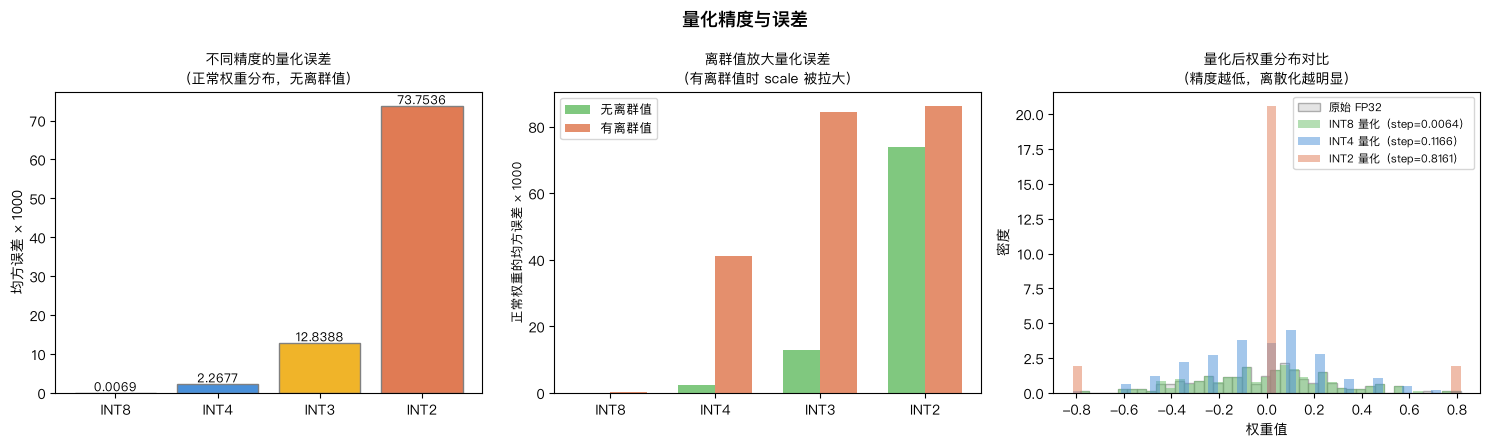


三种模型压缩方法对比：
  方法            压缩比         精度损失        推理加速        是否需要重训      
  ----------------------------------------------------------
  知识蒸馏          2-4×        1-5%        1.5-4×      是（Student）  
  非结构化剪枝        2-10×       1-3%        需专用引擎       可选          
  结构化剪枝         1.5-3×      2-8%        1.5-3×      建议微调        
  INT8 量化       2×          <1%         1.5-2×      否（PTQ）      
  INT4 量化       4×          3-8%        2-3×        否（PTQ）      


In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── 量化误差可视化 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('量化精度与误差', fontsize=13, fontweight='bold')

# 模拟一个正态分布权重 + 少量离群值
weights_clean = np.random.randn(1000) * 0.3
weights_with_outlier = np.append(weights_clean, [3.5, -4.2, 5.1])  # 加入离群值

def quantize(w, n_bits):
    w_max = np.max(np.abs(w))
    scale = w_max / (2**(n_bits-1) - 1)
    w_int = np.round(w / scale).astype(int)
    w_dequant = w_int.astype(float) * scale
    return w_dequant, scale

# 左图：不同精度的量化误差（无离群值）
ax = axes[0]
bit_options = [8, 4, 3, 2]
errors = []
for bits in bit_options:
    w_q, _ = quantize(weights_clean, bits)
    mse = np.mean((weights_clean - w_q)**2)
    errors.append(mse * 1000)  # 转换为 milli

bar_colors = ['#6abf69', '#4a90d9', '#f0b429', '#e07b54']
bars = ax.bar([f'INT{b}' for b in bit_options], errors, color=bar_colors, edgecolor='gray')
ax.set_ylabel('均方误差 × 1000', fontsize=10)
ax.set_title('不同精度的量化误差\n（正常权重分布，无离群值）', fontsize=10)
for bar, e in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, e + 0.001,
            f'{e:.4f}', ha='center', va='bottom', fontsize=9)

# 中图：离群值对量化的影响
ax2 = axes[1]
errors_clean = []
errors_outlier = []
for bits in bit_options:
    wq_c, _ = quantize(weights_clean, bits)
    wq_o, _ = quantize(weights_with_outlier[:-3], bits)  # 无离群值
    wq_out, _ = quantize(weights_with_outlier, bits)     # 有离群值（只计算非离群值部分）
    errors_clean.append(np.mean((weights_clean - wq_c)**2) * 1000)
    errors_outlier.append(np.mean((weights_clean - wq_out[:-3])**2) * 1000)

x = np.arange(len(bit_options))
w = 0.35
b1 = ax2.bar(x - w/2, errors_clean, w, label='无离群值', color='#6abf69', alpha=0.85)
b2 = ax2.bar(x + w/2, errors_outlier, w, label='有离群值', color='#e07b54', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels([f'INT{b}' for b in bit_options])
ax2.set_ylabel('正常权重的均方误差 × 1000', fontsize=9)
ax2.set_title('离群值放大量化误差\n（有离群值时 scale 被拉大）', fontsize=10)
ax2.legend(fontsize=9)

# 右图：不同量化精度下的权重分布直方图对比
ax3 = axes[2]
sample = weights_clean[:200]
colors_line = ['black', '#6abf69', '#4a90d9', '#e07b54']
labels_line = ['原始 FP32', 'INT8 量化', 'INT4 量化', 'INT2 量化']
ax3.hist(sample, bins=40, color='lightgray', edgecolor='gray', alpha=0.6, label='原始 FP32', density=True)
for bits, color, label in zip([8, 4, 2], colors_line[1:], labels_line[1:]):
    w_q, s = quantize(sample, bits)
    ax3.hist(w_q, bins=40, color=color, alpha=0.5, label=f'{label}（step={s:.4f}）', density=True)
ax3.set_xlabel('权重值', fontsize=10)
ax3.set_ylabel('密度', fontsize=10)
ax3.set_title('量化后权重分布对比\n（精度越低，离散化越明显）', fontsize=10)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 三种压缩方法汇总 ───────────────────────────────────────────────────────
print()
print('三种模型压缩方法对比：')
print(f'  {"方法":<12}  {"压缩比":<10}  {"精度损失":<10}  {"推理加速":<10}  {"是否需要重训":<12}')
print('  ' + '-' * 58)
rows = [
    ('知识蒸馏',   '2-4×',   '1-5%',  '1.5-4×',  '是（Student）'),
    ('非结构化剪枝','2-10×',  '1-3%',  '需专用引擎', '可选'),
    ('结构化剪枝', '1.5-3×', '2-8%',  '1.5-3×',  '建议微调'),
    ('INT8 量化',  '2×',     '<1%',   '1.5-2×',  '否（PTQ）'),
    ('INT4 量化',  '4×',     '3-8%',  '2-3×',    '否（PTQ）'),
]
for row in rows:
    print(f'  {row[0]:<12}  {row[1]:<10}  {row[2]:<10}  {row[3]:<10}  {row[4]:<12}')